# Sheet 04: Machine Learning Model Development

Train a supervised classification model to predict `resistance_level`
(Low / Medium / High) from country, year, bacterium, antibiotic, and region.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("../data/processed/ears_net_clean.csv")
print("Loaded:", df.shape)
print("Columns:", list(df.columns))
df.head()

Loaded: (3422, 8)
Columns: ['country', 'year', 'bacterium', 'antibiotic', 'n_isolates', 'pct_resistant', 'resistance_level', 'region']


,country,year,bacterium,antibiotic,n_isolates,pct_resistant,resistance_level,region
0,Austria,2013,Acinetobacter spp.,Aminoglycosides,51.0,9.80000,Low,Western
1,Austria,2014,Acinetobacter spp.,Aminoglycosides,79.0,8.86076,Low,Western
2,Bulgaria,2012,Acinetobacter spp.,Aminoglycosides,65.0,58.50000,High,Eastern
3,Bulgaria,2013,Acinetobacter spp.,Aminoglycosides,91.0,58.20000,High,Eastern
4,Bulgaria,2014,Acinetobacter spp.,Aminoglycosides,99.0,63.63636,High,Eastern


## Selecting Features (X) and Target (y)

- **Target (y):** `resistance_level` (Low / Medium / High)
- **Features (X):** country, year, bacterium, antibiotic, region

**Excluded:** `pct_resistant` and `n_isolates`. Since `resistance_level` was
derived from `pct_resistant`, including it would cause **target leakage** — the
model would trivially reverse the binning rule. Excluding it makes the model
learn genuine patterns from place, time, organism, and drug.

In [2]:
feature_cols = ['country', 'year', 'bacterium', 'antibiotic', 'region']
target_col = 'resistance_level'

X = df[feature_cols]
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget classes:", y.unique())
X.head()

X shape: (3422, 5)
y shape: (3422,)

Target classes: <StringArray>
['Low', 'High', 'Medium']
Length: 3, dtype: str


,country,year,bacterium,antibiotic,region
0,Austria,2013,Acinetobacter spp.,Aminoglycosides,Western
1,Austria,2014,Acinetobacter spp.,Aminoglycosides,Western
2,Bulgaria,2012,Acinetobacter spp.,Aminoglycosides,Eastern
3,Bulgaria,2013,Acinetobacter spp.,Aminoglycosides,Eastern
4,Bulgaria,2014,Acinetobacter spp.,Aminoglycosides,Eastern


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nTraining target balance:")
print(y_train.value_counts())

Training set: (2737, 5)
Testing set: (685, 5)

Training target balance:
resistance_level
Low       1140
High       824
Medium     773
Name: count, dtype: int64


## Encoding Categorical Features

Machine learning models require numeric input, but our features are text
(country, bacterium, antibiotic, region). We apply **one-hot encoding** to convert
each category into binary 0/1 columns. `year` is already numeric and is passed
through unchanged. We fit the encoder on the training data only, then apply it to
the test data, to avoid leaking information from the test set.

In [4]:
categorical_features = ['country', 'bacterium', 'antibiotic', 'region']
numeric_features = ['year']

# ColumnTransformer applies one-hot encoding to text columns, leaves 'year' as-is
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

# Fit on TRAINING data, transform both train and test
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)
print(f"\nWent from {X_train.shape[1]} columns to {X_train_encoded.shape[1]} columns after encoding.")

Encoded training shape: (2737, 56)
Encoded testing shape: (685, 56)

Went from 5 columns to 56 columns after encoding.


## Training the Model: Random Forest Classifier

I chose a **Random Forest** because:
- All features are categorical — tree-based models excel at learning categorical rules.
- It captures **interactions** between features (e.g. specific bacterium–antibiotic
  combinations), which resistance depends on.
- As an ensemble of many decision trees that vote, it is robust and resistant to overfitting.
- It provides **feature importance**, showing which factors most drive resistance.

In [5]:
# Create and train the Random Forest
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train_encoded, y_train)

print("Model trained successfully!")

# Quick check: accuracy on the training data itself
train_accuracy = model.score(X_train_encoded, y_train)
print(f"Training accuracy: {train_accuracy:.3f}")

Model trained successfully!
Training accuracy: 1.000


## Model Evaluation on the Test Set

Training accuracy (100%) only shows the model memorised the data it saw. The honest
measure is performance on the **held-out test set** (685 rows never seen during training).
Below: overall accuracy, a per-class breakdown (precision, recall, F1), and a confusion
matrix showing exactly where predictions succeed or fail.

In [6]:
# Make predictions on the UNSEEN test data
y_pred = model.predict(X_test_encoded)

# 1. Overall accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"TEST ACCURACY: {test_accuracy:.3f}  ({test_accuracy*100:.1f}%)")

# 2. Detailed per-class report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

TEST ACCURACY: 0.851  (85.1%)

--- Classification Report ---
              precision    recall  f1-score   support

        High       0.90      0.87      0.88       206
         Low       0.90      0.91      0.90       285
      Medium       0.74      0.75      0.74       194

    accuracy                           0.85       685
   macro avg       0.84      0.84      0.84       685
weighted avg       0.85      0.85      0.85       685



## Confusion Matrix & Feature Importance

The confusion matrix shows exactly which classes get confused with which. Feature
importance reveals which inputs most drive the model's predictions.

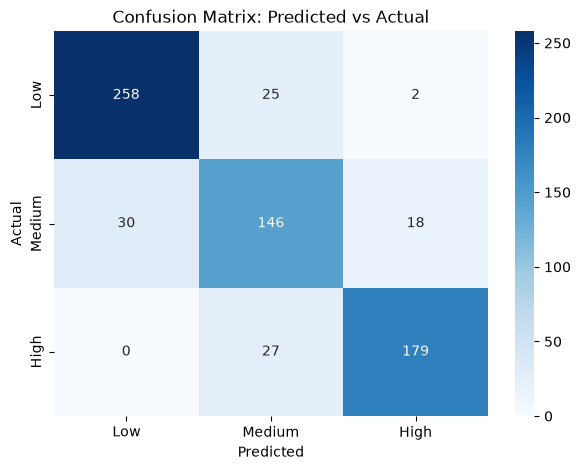

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Confusion Matrix ---
labels = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: Predicted vs Actual')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

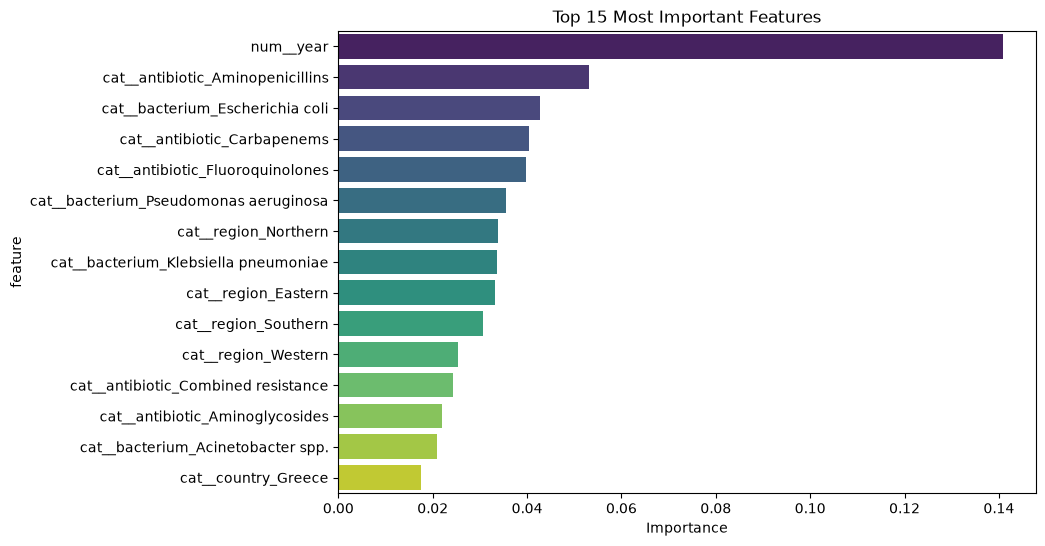

                              feature  importance
                            num__year    0.140793
     cat__antibiotic_Aminopenicillins    0.053176
      cat__bacterium_Escherichia coli    0.042766
          cat__antibiotic_Carbapenems    0.040489
     cat__antibiotic_Fluoroquinolones    0.039797
cat__bacterium_Pseudomonas aeruginosa    0.035471
                 cat__region_Northern    0.033774
 cat__bacterium_Klebsiella pneumoniae    0.033660
                  cat__region_Eastern    0.033157
                 cat__region_Southern    0.030682
                  cat__region_Western    0.025290
  cat__antibiotic_Combined resistance    0.024260
      cat__antibiotic_Aminoglycosides    0.021934
    cat__bacterium_Acinetobacter spp.    0.020912
                  cat__country_Greece    0.017412


In [8]:
# --- Feature Importance ---
# Get the encoded feature names
encoded_names = preprocessor.get_feature_names_out()
importances = model.feature_importances_

# Put into a DataFrame and take the top 15
feat_imp = pd.DataFrame({'feature': encoded_names, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=feat_imp, x='importance', y='feature', palette='viridis', hue='feature', legend=False)
plt.title('Top 15 Most Important Features')
plt.xlabel('Importance')
plt.show()

print(feat_imp.to_string(index=False))

## Evaluation Summary

- **Test accuracy: 85.1%** on 685 unseen rows — far above the ~33% random baseline
  for three classes.
- **Per class:** Low (F1 0.90) and High (F1 0.88) are predicted excellently; Medium
  (F1 0.74) is weakest because it is the boundary band, easily confused with adjacent
  classes near the 10% and 25% thresholds.
- **Confusion matrix:** Low↔High confusion is near-zero (2 and 0 errors). The model
  never mislabels a high-resistance case as low — the errors it makes are "safe."
- **Feature importance:** `year`, `Aminopenicillins`, and the regional features dominate,
  directly matching the EDA findings (rising trend, worst antibiotic, North–South gradient).
  The engineered `region` feature ranked among the top predictors.

In [9]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

# Save both the model and the preprocessor (both needed to make predictions later)
joblib.dump(model, "../models/resistance_model.pkl")
joblib.dump(preprocessor, "../models/preprocessor.pkl")

print("Model and preprocessor saved to ../models/")

Model and preprocessor saved to ../models/
